<a href="https://colab.research.google.com/github/saniya236/SANIYA/blob/main/Ai_powered_resume_acreening_automation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pdfplumber python-docx spacy scikit-learn pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 76.4 MB/s eta 0:00:00


In [8]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 80.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [9]:
from google.colab import files
uploaded = files.upload()

Saving MohammedSaniyaAsadResume.pdf to MohammedSaniyaAsadResume (1).pdf


In [12]:
import pdfplumber

text = ""

with pdfplumber.open("MohammedSaniyaAsadResume.pdf") as pdf:
    for page in pdf.pages:
        text += page.extract_text()

print(text)

MOHAMMED SANIYA ASAD
BCA DATA SCIENCE GRADUATE | Python | Java | SQL | OOPS | Data Structures
​ 8008763645 ​ saniyaasad23@gmail.com ​ https://www.linkedin.com/in/saniya-asad-938728361/
​ https://github.com/saniya236 ​ Andhra Pradesh, Kakinada
CAREER OBJECTIVE EDUCATIONAL QUALIFICATION
Student of BCA DATA SCIENCE with hands-on exposure to Java, Python, SQL BCA DATA SCIENCE
Experienced in working across design, development, testing, and analysis Aditya Degree College for Women, Kakinada
phases through academic projects and internships. Strong analytical 2023 - 2026 CGPA
mindset with the ability to understand business problems, collaborate with Kakinada 8.0 / 10.0
stakeholders, and deliver reliable technology-driven solutions aligned with
hybrid cloud and AI transformation goals.
SKILLS
PROJECTS Programming Languages: Python, C, Java (Basic)
Databases: SQL, DBMS
WEATHER PREDICTION
Data & Analytics Tools: Power BI, Tableau, MS
Kakinada Excel
• Built a machine learning model to forecast wea

In [13]:
import spacy

nlp = spacy.load("en_core_web_sm")

doc = nlp(text.lower())

tokens = [token.text for token in doc if not token.is_stop]

In [16]:
skills = [
    "python",
    "java",
    "c",
    "sql",
    "dbms",
    "power bi",
    "tableau",
    "machine learning",
    "html",
    "css",
    "excel",
    "automation anywhere"
]

found_skills = []

for skill in skills:

    if skill.lower() in cleaned_text:
        found_skills.append(skill)

print("Detected Skills:")
print(found_skills)

Detected Skills:
['python', 'java', 'c', 'sql', 'dbms', 'power bi', 'tableau', 'machine learning', 'html', 'css', 'excel']


In [17]:
job_description = """

Looking for a Data Analyst with skills in Python,
SQL, Power BI, Tableau, Excel, and Machine Learning.

"""

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

documents = [cleaned_text, job_description]

tfidf = TfidfVectorizer()

matrix = tfidf.fit_transform(documents)

similarity_score = cosine_similarity(matrix[0:1], matrix[1:2])

match_percentage = similarity_score[0][0] * 100

print("Resume Match Percentage:")
print(round(match_percentage, 2), "%")

Resume Match Percentage:
21.98 %


In [19]:
score = 0

# Skills score
score += len(found_skills) * 5

# Similarity score
score += match_percentage * 0.5

print("Final Resume Score:")
print(round(score, 2))

Final Resume Score:
65.99


In [20]:
if match_percentage >= 70:
    print("Candidate Shortlisted")
else:
    print("Candidate Rejected")

Candidate Rejected


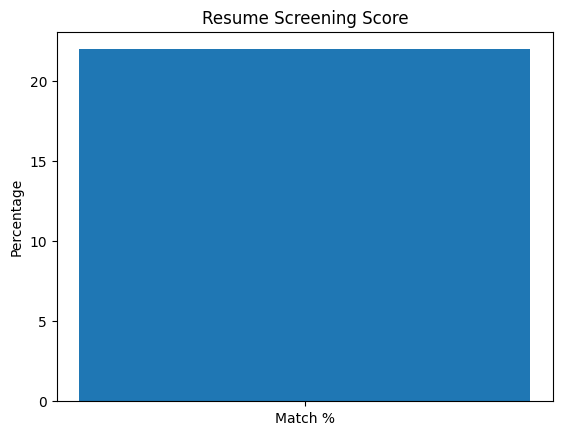

In [21]:
import matplotlib.pyplot as plt

labels = ['Match %']
values = [match_percentage]

plt.bar(labels, values)

plt.ylabel("Percentage")
plt.title("Resume Screening Score")

plt.show()